## 기본 통계량 및 분포 분석

# 지역별 숙소 개수 -> 현황 및 시각화 추가 할 거 있으면 추가

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [60]:
df_clean = pd.read_csv("data/first_clean_data.csv")
clean = df_clean.copy()

In [61]:
clean.shape

(22248, 39)

In [73]:
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 22248 entries, 0 to 22247
Data columns (total 39 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Unnamed: 0                                    22248 non-null  int64  
 1   id                                            22248 non-null  int64  
 2   name                                          22248 non-null  str    
 3   description                                   22248 non-null  str    
 4   host_id                                       22248 non-null  int64  
 5   host_since                                    22248 non-null  str    
 6   host_response_time                            22248 non-null  float64
 7   host_response_rate                            22248 non-null  float64
 8   host_acceptance_rate                          22248 non-null  float64
 9   host_is_superhost                             22248 non-null  str    
 1

In [62]:
clean['neighbourhood_group_cleansed'].value_counts()

neighbourhood_group_cleansed
Manhattan        10165
Brooklyn          7442
Queens            3414
Bronx              911
Staten Island      316
Name: count, dtype: int64

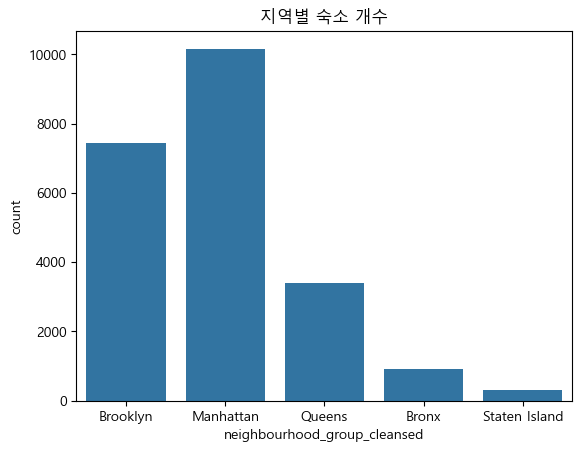

In [63]:
sns.countplot(data=clean, x='neighbourhood_group_cleansed') 
plt.title('지역별 숙소 개수')
plt.show()

1. 시각화 해석
- 뉴욕airbnb숙소는 manhattan과 brooklyn 지역에 많이 분포되어 있고 특히 manhattan이 가장 많은 숙소를 보유한 지역으로 나타남. 반면 bronx랑 statenlsland는 다른 지역에 비해 상대적으로 적은 숙소수를 나타내고 있다.

In [64]:
clean['room_type'].value_counts()

room_type
Entire home/apt    12635
Private room        9178
Hotel room           365
Shared room           70
Name: count, dtype: int64

# 지역별 숙소 유형 개수(한번 확인해봤음)

In [65]:
pd.crosstab(clean['neighbourhood_group_cleansed'],clean['room_type']).reset_index()

room_type,neighbourhood_group_cleansed,Entire home/apt,Hotel room,Private room,Shared room
0,Bronx,370,0,541,0
1,Brooklyn,3772,17,3623,30
2,Manhattan,6928,340,2880,17
3,Queens,1408,8,1975,23
4,Staten Island,157,0,159,0


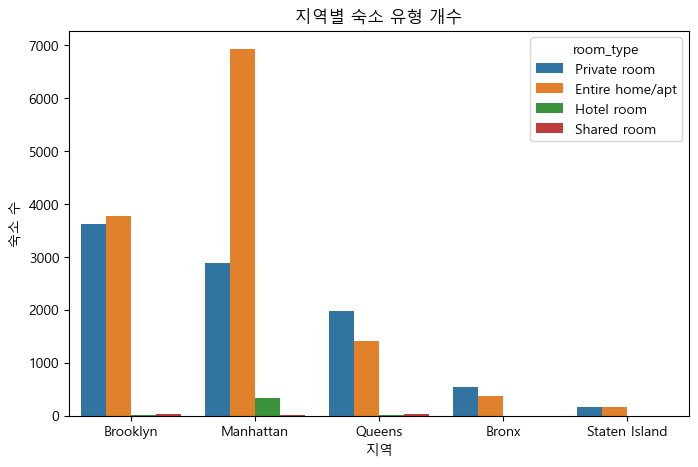

In [66]:
plt.figure(figsize=(8,5))
sns.countplot(data=clean, x='neighbourhood_group_cleansed', hue='room_type')
plt.title('지역별 숙소 유형 개수')
plt.xlabel('지역')
plt.ylabel('숙소 수')
plt.show()

1. 시각화 해석
- 지역별 숙소 유형 분포를 살펴보면 Entire home/apt 유형은 Manhattan 지역에서 가장 높은 비중을 차지하는 것으로 나타났고, 반면 Private room 유형은 Brooklyn 지역에서 상대적으로 더 많이 분포하는 경향을 보인다. 나머지는 뭐....

# 개수보단 비율로 시각화 한번 도전!

In [67]:
pd.crosstab(clean['neighbourhood_group_cleansed'], clean['room_type'], normalize='index').round(2)

room_type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood_group_cleansed,,,,
Bronx,0.41,0.00,0.59,0.00
Brooklyn,0.51,0.00,0.49,0.00
Manhattan,0.68,0.03,0.28,0.00
Queens,0.41,0.00,0.58,0.01
Staten Island,0.50,0.00,0.50,0.00


In [68]:
# normalize로 비율 분석(지역별 숙소유형 개수 시각화)
ct = pd.crosstab(clean['neighbourhood_group_cleansed'], clean['room_type'], normalize='index').round(2)

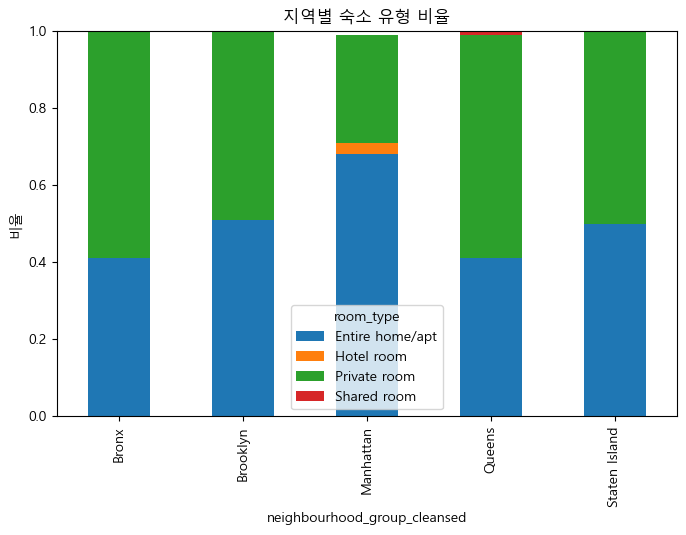

In [69]:
# 음... 망했다....
ct.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.title("지역별 숙소 유형 비율")
plt.ylabel("비율")
plt.show()

In [70]:
# 지역별 숙소 개수 비율로 시각화
clean['neighbourhood_group_cleansed'].value_counts(normalize=False)

neighbourhood_group_cleansed
Manhattan        10165
Brooklyn          7442
Queens            3414
Bronx              911
Staten Island      316
Name: count, dtype: int64

In [71]:
region = clean['neighbourhood_group_cleansed'].value_counts(normalize=True) * 100
region = region.round(2)

region

neighbourhood_group_cleansed
Manhattan        45.69
Brooklyn         33.45
Queens           15.35
Bronx             4.09
Staten Island     1.42
Name: proportion, dtype: float64

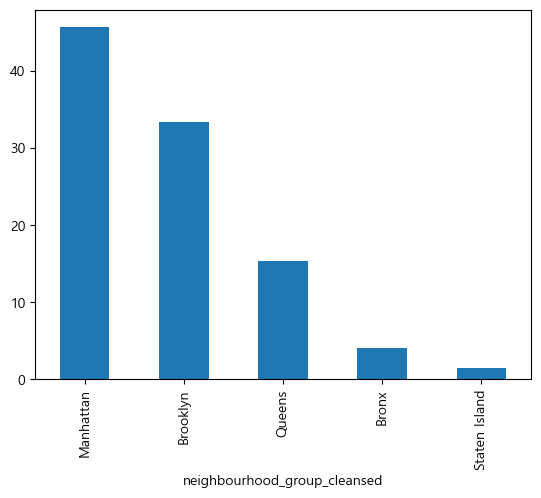

In [72]:
region.plot(kind='bar')
plt.show()